In [1]:
pip install arch

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("btcusd_1-min_data.csv")

df["date"] = pd.to_datetime(df["Timestamp"], unit="s")

df = df.set_index("date")

df = df[["Open","High","Low","Close","Volume"]]

df = df.dropna()

btc_daily = df["Close"].resample("1D").last()

btc_daily = btc_daily.to_frame()

btc_daily["return_pct"] = btc_daily["Close"].pct_change()*100

btc_daily = btc_daily.dropna()

data = btc_daily.copy()

In [9]:
split = int(len(data)*0.8)

train = data.iloc[:split]
test = data.iloc[split:]

In [11]:
# Fit GARCH model

from arch import arch_model

garch = arch_model(
    train["return_pct"],
    mean="constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

garch_res = garch.fit(disp="off")
print(garch_res.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   return_pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -10760.6
Distribution:      Standardized Student's t   AIC:                           21531.2
Method:                  Maximum Likelihood   BIC:                           21562.9
                                              No. Observations:                 4148
Date:                      Fri, Mar 13 2026   Df Residuals:                     4147
Time:                              19:26:17   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0

In [13]:
# Rolling forecast for test set

import numpy as np
import pandas as pd

def rolling_garch_forecast(series, split_idx):
    forecast_var = []
    forecast_mean = []
    forecast_index = []

    for i in range(split_idx, len(series)):
        train_slice = series.iloc[:i]

        model = arch_model(
            train_slice,
            mean="constant",
            vol="GARCH",
            p=1,
            q=1,
            dist="t"
        )

        res = model.fit(disp="off")

        fcast = res.forecast(horizon=1, reindex=False)

        pred_var = fcast.variance.values[-1, 0]
        pred_mean = fcast.mean.values[-1, 0]

        forecast_var.append(pred_var)
        forecast_mean.append(pred_mean)
        forecast_index.append(series.index[i])

    return pd.DataFrame({
        "mean_forecast": forecast_mean,
        "variance_forecast": forecast_var
    }, index=forecast_index)

forecast_df = rolling_garch_forecast(data["return_pct"], split)
forecast_df.head()

,mean_forecast,variance_forecast
2023-05-12,0.171455,9.586591
2023-05-13,0.170902,8.800591
2023-05-14,0.171292,7.998863
2023-05-15,0.171158,7.077779
2023-05-16,0.171860,6.759373


In [15]:
# Calculate Parametric VaR

nu = garch_res.params["nu"]

q_5 = garch.distribution.ppf(0.05, nu)
q_1 = garch.distribution.ppf(0.01, nu)

forecast_df["vol_forecast"] = np.sqrt(forecast_df["variance_forecast"])

forecast_df["VaR_5_parametric"] = (
    forecast_df["mean_forecast"] + forecast_df["vol_forecast"] * q_5
)

forecast_df["VaR_1_parametric"] = (
    forecast_df["mean_forecast"] + forecast_df["vol_forecast"] * q_1
)

In [17]:
# Calculate Empirical VaR

std_resid = pd.Series(garch_res.std_resid).dropna()

q_5_emp = std_resid.quantile(0.05)
q_1_emp = std_resid.quantile(0.01)

forecast_df["VaR_5_empirical"] = (
    forecast_df["mean_forecast"] + forecast_df["vol_forecast"] * q_5_emp
)

forecast_df["VaR_1_empirical"] = (
    forecast_df["mean_forecast"] + forecast_df["vol_forecast"] * q_1_emp
)

In [19]:
# Plug actual returns into forecast table

forecast_df["actual_return"] = test["return_pct"].reindex(forecast_df.index)
forecast_df = forecast_df.dropna()
forecast_df.head()

,mean_forecast,variance_forecast,vol_forecast,VaR_5_parametric,VaR_1_parametric,VaR_5_empirical,VaR_1_empirical,actual_return
2023-05-12,0.171455,9.586591,3.096222,-4.291027,-8.054493,-4.715386,-8.751245,-1.411440
2023-05-13,0.170902,8.800591,2.966579,-4.104730,-7.710614,-4.511320,-8.378192,1.435425
2023-05-14,0.171292,7.998863,2.828226,-3.904936,-7.342652,-4.292565,-7.979097,0.141511
2023-05-15,0.171158,7.077779,2.660410,-3.663202,-6.896937,-4.027831,-7.495617,1.941170
2023-05-16,0.171860,6.759373,2.599879,-3.575260,-6.735420,-3.931592,-7.320479,-1.747346


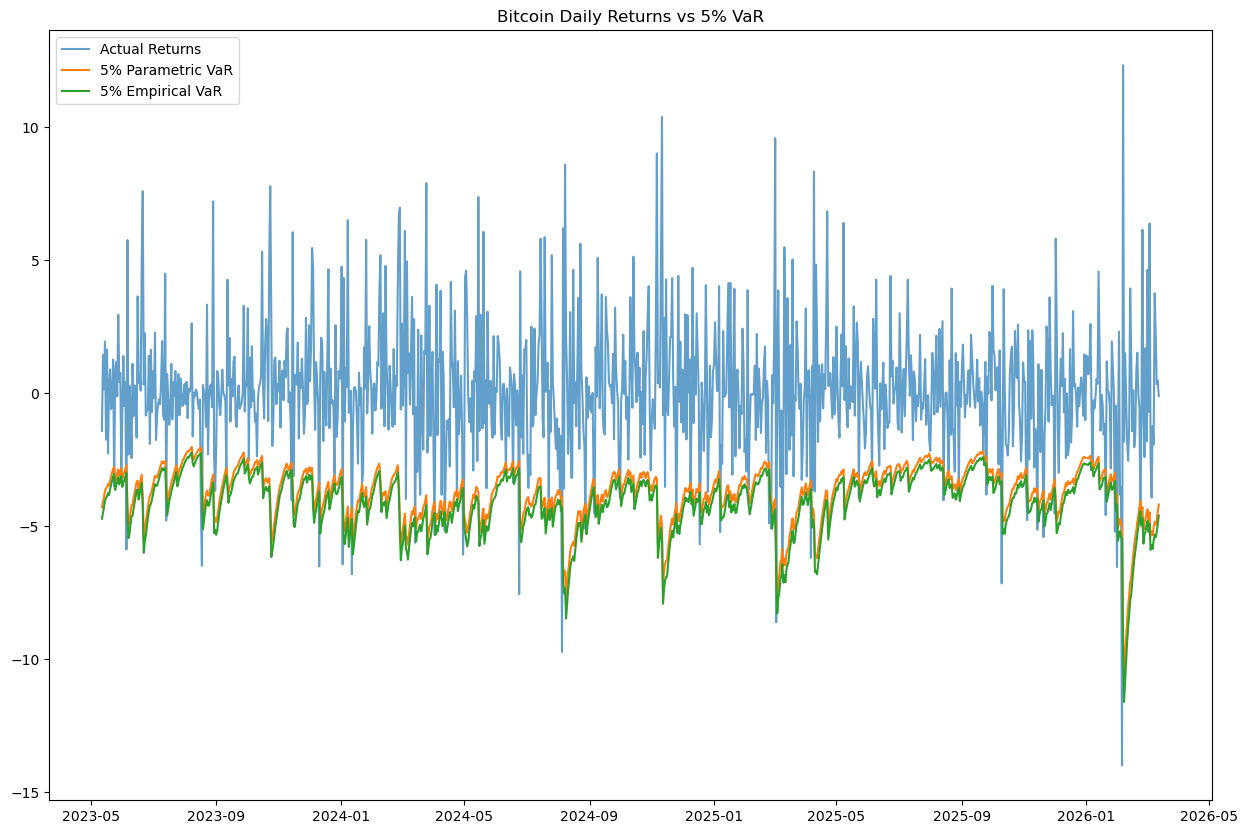

In [25]:
# Plot VaR vs actual returns

# 5% VaR
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.plot(forecast_df.index, forecast_df["actual_return"], label="Actual Returns", alpha=0.7)
plt.plot(forecast_df.index, forecast_df["VaR_5_parametric"], label="5% Parametric VaR")
plt.plot(forecast_df.index, forecast_df["VaR_5_empirical"], label="5% Empirical VaR")
plt.title("Bitcoin Daily Returns vs 5% VaR")
plt.legend()
plt.show()

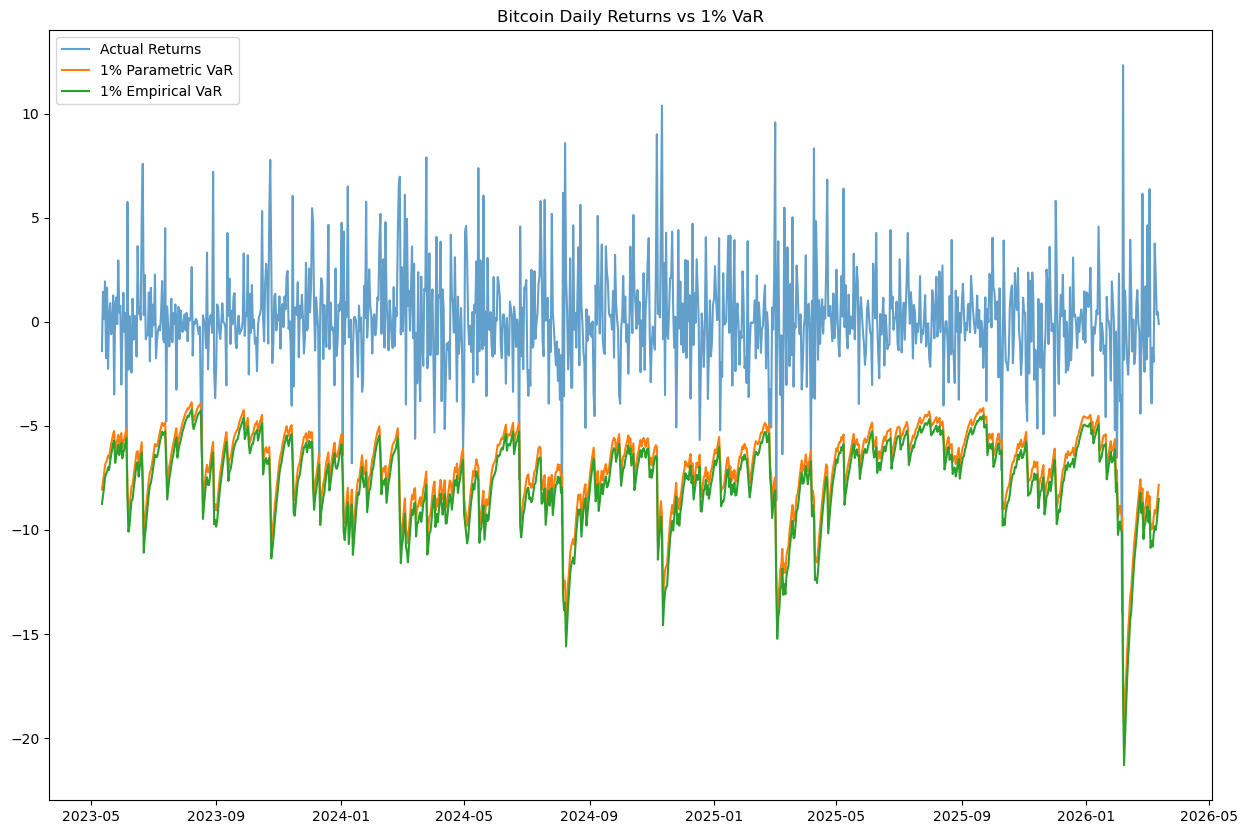

In [27]:
# 1% VaR

plt.figure(figsize=(15, 10))
plt.plot(forecast_df.index, forecast_df["actual_return"], label="Actual Returns", alpha=0.7)
plt.plot(forecast_df.index, forecast_df["VaR_1_parametric"], label="1% Parametric VaR")
plt.plot(forecast_df.index, forecast_df["VaR_1_empirical"], label="1% Empirical VaR")
plt.title("Bitcoin Daily Returns vs 1% VaR")
plt.legend()
plt.show()

In [31]:
# Backtest VaR exceedances

# 5% exceedances

forecast_df["exceed_5_parametric"] = (
    forecast_df["actual_return"] < forecast_df["VaR_5_parametric"]
)

forecast_df["exceed_5_empirical"] = (
    forecast_df["actual_return"] < forecast_df["VaR_5_empirical"]
)

# 1% exceedances

forecast_df["exceed_1_parametric"] = (
    forecast_df["actual_return"] < forecast_df["VaR_1_parametric"]
)

forecast_df["exceed_1_empirical"] = (
    forecast_df["actual_return"] < forecast_df["VaR_1_empirical"]
)

In [33]:
# Calculate exceedance rate

backtest_summary = pd.DataFrame({
    "Model": [
        "5% Parametric",
        "5% Empirical",
        "1% Parametric",
        "1% Empirical"
    ],
    "Expected Rate": [0.05, 0.05, 0.01, 0.01],
    "Observed Rate": [
        forecast_df["exceed_5_parametric"].mean(),
        forecast_df["exceed_5_empirical"].mean(),
        forecast_df["exceed_1_parametric"].mean(),
        forecast_df["exceed_1_empirical"].mean()
    ]
})

backtest_summary["Difference"] = (
    backtest_summary["Observed Rate"] - backtest_summary["Expected Rate"]
)

backtest_summary

,Model,Expected Rate,Observed Rate,Difference
0,5% Parametric,0.05,0.052073,0.002073
1,5% Empirical,0.05,0.042430,-0.007570
2,1% Parametric,0.01,0.008679,-0.001321
3,1% Empirical,0.01,0.005786,-0.004214


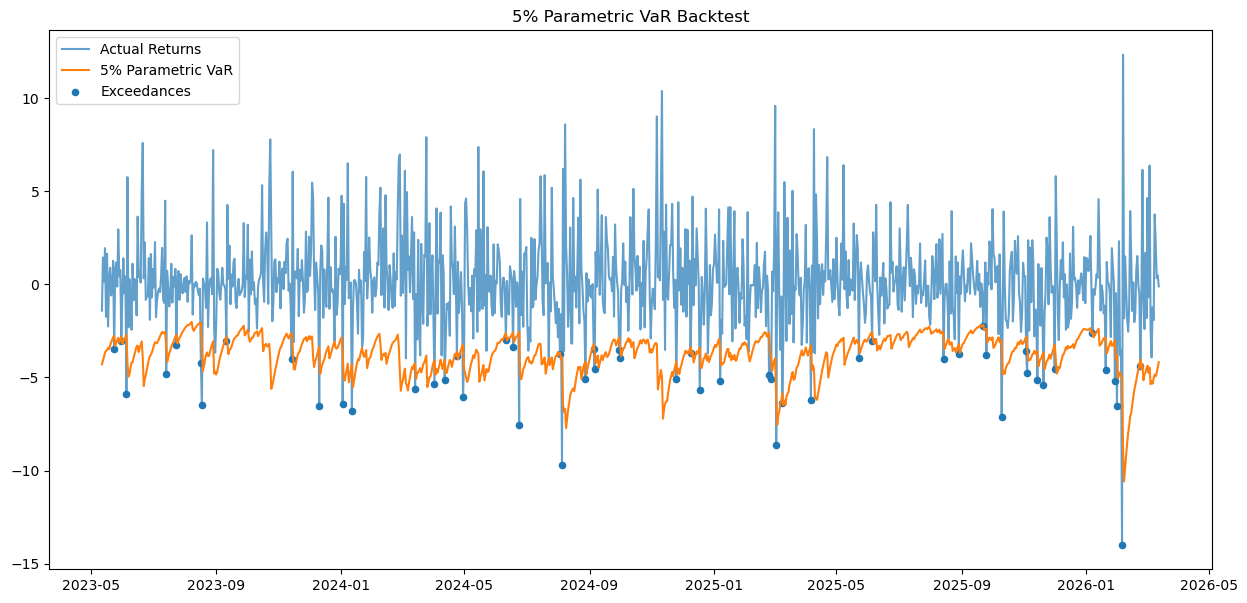

In [39]:
# Plot exceedances

# 5% Parametric exceedances
plt.figure(figsize=(15, 7))
plt.plot(forecast_df.index, forecast_df["actual_return"], label="Actual Returns", alpha=0.7)
plt.plot(forecast_df.index, forecast_df["VaR_5_parametric"], label="5% Parametric VaR")

mask = forecast_df["exceed_5_parametric"]
plt.scatter(
    forecast_df.index[mask],
    forecast_df.loc[mask, "actual_return"],
    label="Exceedances",
    s=20
)

plt.title("5% Parametric VaR Backtest")
plt.legend()
plt.show()

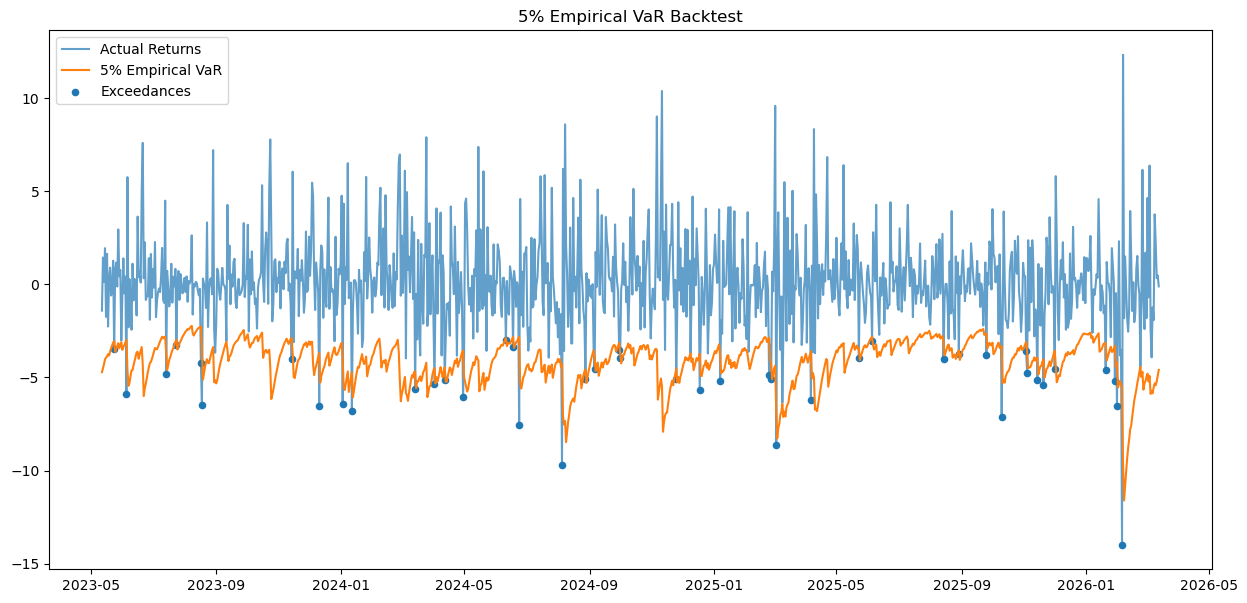

In [41]:
# 5% Empirical exceedances
plt.figure(figsize=(15, 7))
plt.plot(forecast_df.index, forecast_df["actual_return"], label="Actual Returns", alpha=0.7)
plt.plot(forecast_df.index, forecast_df["VaR_5_empirical"], label="5% Empirical VaR")

mask = forecast_df["exceed_5_empirical"]
plt.scatter(
    forecast_df.index[mask],
    forecast_df.loc[mask, "actual_return"],
    label="Exceedances",
    s=20
)

plt.title("5% Empirical VaR Backtest")
plt.legend()
plt.show()

In [ ]:
# Compare average VaR levels

